# NB05 v2 — Transformer Fine-Tuning (Multi-Task, Consolidated Labels)

Changes from v1:
- `label_type` consolidated from 89 → 9 canonical classes before encoding
- Enables meaningful multi-task training (binary + abuse_type)

**Requires GPU.** ~3hrs on T4 for 3 models × 3 seeds.

In [1]:
# ── Install dependencies (run once) ────────────────────────────────────────
!pip install transformers datasets accelerate scikit-learn pandas matplotlib seaborn -q

In [2]:
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer, AutoModel, AutoConfig,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    f1_score, accuracy_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_auc_score
)

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # FIXED: use 'total_memory' instead of 'total_mem'
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Memory: 17.1 GB


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

CONFIG = {
    "models": {
        "banglabert": "csebuetnlp/banglabert",
        "muril": "google/muril-base-cased",
        "xlmr": "xlm-roberta-base",
    },
    "max_length": 128,
    "batch_size": 32,       # Reduce to 16 if GPU OOM
    "epochs": 10,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "lr_decay_factor": 0.95,
    "focal_gamma": 2.0,
    "patience": 3,
    "seeds": [42, 123, 456],
    "use_fp16": torch.cuda.is_available(),
}

# ── Multi-task head config ──────────────────────────────────────────────────
TASK_CONFIG = {
    "binary": {
        "col": "label_binary",
        "num_classes": 2,
        "loss_weight": 1.0,
        "is_primary": True,
    },
    "abuse_type": {
        "col": "label_type",
        "num_classes": None,
        "loss_weight": 0.5,
        "is_primary": False,
    },
    "severity": {
        "col": "label_severity",
        "num_classes": None,
        "loss_weight": 0.3,
        "is_primary": False,
    },
}

# ── Run control ─────────────────────────────────────────────────────────────
# Keep old runs in ../outputs/models untouched.
# New fixed runs go here.
OUTPUT_DIR = "../outputs/models_v2_fix"

# First verification run only: 1 model × 1 seed
RUN_MODELS = ["banglabert"]      # later: list(CONFIG["models"].keys())
RUN_SEEDS  = [42]                # later: CONFIG["seeds"]

# False = skip already completed valid runs inside OUTPUT_DIR
# True  = retrain even if checkpoint exists in OUTPUT_DIR
FORCE_RETRAIN = False

print(json.dumps(CONFIG, indent=2, default=str))
print(f"\nOUTPUT_DIR : {OUTPUT_DIR}")
print(f"RUN_MODELS : {RUN_MODELS}")
print(f"RUN_SEEDS  : {RUN_SEEDS}")
print(f"FORCE_RETRAIN: {FORCE_RETRAIN}")


{
  "models": {
    "banglabert": "csebuetnlp/banglabert",
    "muril": "google/muril-base-cased",
    "xlmr": "xlm-roberta-base"
  },
  "max_length": 128,
  "batch_size": 32,
  "epochs": 10,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "lr_decay_factor": 0.95,
  "focal_gamma": 2.0,
  "patience": 3,
  "seeds": [
    42,
    123,
    456
  ],
  "use_fp16": true
}


In [4]:
# ── Load data ──────────────────────────────────────────────────────────────
SPLIT_DIR = "../data/splits"

train_df = pd.read_csv(f"{SPLIT_DIR}/random_train.csv")
val_df   = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df  = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")


Train: 108,460  Val: 13,557  Test: 13,558
Task 'binary': 2 classes
Task 'abuse_type': 89 classes
Task 'severity': column 'label_severity' not found — SKIPPED

Active tasks: ['binary', 'abuse_type']


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# LABEL CONSOLIDATION: 89 raw label_type categories → 9 canonical classes
# ══════════════════════════════════════════════════════════════════════════════

TYPE_MAP = {
    # none / not bullying
    'none': 'none', 'not bully': 'none',

    # sexual
    'sexual': 'sexual',

    # threat / call to violence
    'threat': 'threat', 'threat,spam': 'threat',
    'callToViolence': 'threat', 'callToViolence_slander': 'threat',
    'callToViolence_gender': 'threat', 'callToViolence_religion': 'threat',
    'callToViolence_religion_slander': 'threat',
    'callToViolence_gender_religion_slander': 'threat',
    'callToViolence_gender_slander': 'threat',
    'religious,threat': 'threat', 'sexual,threat': 'threat',
    'sexual,religious,threat': 'threat',

    # religious
    'religious': 'religious', 'Religious': 'religious',
    'religion': 'religious', 'religious,spam': 'religious',
    'religion_slander': 'religious',
    'gender_religion': 'religious', 'gender_religion_slander': 'religious',
    'sexual,religious': 'religious',

    # gender
    'gender': 'gender', 'Gender': 'gender', 'gender_slander': 'gender',

    # political
    'Political': 'political',

    # personal
    'Personal Offense': 'personal', 'Body Shaming': 'personal',
    'Origin': 'personal', 'slander': 'personal', 'Misc': 'personal',

    # abusive
    'Abusive/Violence': 'abusive', 'troll': 'abusive',

    # other
    'spam': 'other',
}

PRIORITY = ['threat', 'sexual', 'religious', 'gender', 'political',
            'abusive', 'personal', 'other', 'none']

def consolidate_type(val):
    if not isinstance(val, str) or val.strip() == '':
        return 'none'
    val = val.strip()

    if val in TYPE_MAP:
        return TYPE_MAP[val]

    parts = [v.strip() for v in val.replace(',', '|').replace(';', '|').split('|')]
    candidates = [TYPE_MAP[p] for p in parts if p in TYPE_MAP]
    if candidates:
        for pc in PRIORITY:
            if pc in candidates:
                return pc

    for key, mapped in TYPE_MAP.items():
        if key.lower() in val.lower():
            return mapped

    return 'other'

# Apply consolidation BEFORE building label encoders
for df_ in [train_df, val_df, test_df]:
    if 'label_type' in df_.columns:
        df_['label_type'] = df_['label_type'].apply(consolidate_type)

print("Consolidated label_type classes:")
if 'label_type' in train_df.columns:
    all_types = pd.concat([train_df['label_type'], val_df['label_type'], test_df['label_type']])
    print(sorted(all_types.dropna().unique()))
    print(f"Total consolidated classes: {all_types.dropna().nunique()}")

# ── Auto-detect label classes and create encodings ──────────────────────────
label_encoders = {}
active_tasks = {}

for task_name, task_cfg in TASK_CONFIG.items():
    col = task_cfg["col"]
    if col in train_df.columns:
        all_vals = pd.concat([train_df[col], val_df[col], test_df[col]]).dropna().unique()
        label_map = {v: i for i, v in enumerate(sorted(all_vals))}
        label_encoders[task_name] = label_map
        task_cfg["num_classes"] = len(label_map)
        active_tasks[task_name] = task_cfg
        print(f"Task '{task_name}': {len(label_map)} classes")
    else:
        print(f"Task '{task_name}': column '{col}' not found — SKIPPED")

print(f"\nActive tasks: {list(active_tasks.keys())}")


Consolidated label_type: 89 → 9 classes
label_type
none         62473
abusive      12646
personal     10974
sexual        8708
religious     7384
threat        3071
political     1858
other          741
gender         605

Class distribution (train):
label_type
none         57.6
abusive      11.7
personal     10.1
sexual        8.0
religious     6.8
threat        2.8
political     1.7
other         0.7
gender        0.6


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# DATASET CLASS
# ══════════════════════════════════════════════════════════════════════════════

class CyberBullyDataset(Dataset):
    def __init__(self, df, tokenizer, max_length, active_tasks, label_encoders):
        self.texts = df["text_clean"].fillna("").tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        self.labels = {}
        for task_name, task_cfg in active_tasks.items():
            col = task_cfg["col"]
            enc = label_encoders[task_name]
            self.labels[task_name] = [
                enc.get(v, -1) for v in df[col].fillna("unknown")
            ]
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        for task_name in self.labels:
            item[f"label_{task_name}"] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)
        return item

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# MULTI-TASK TRANSFORMER MODEL
# ══════════════════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    """Focal Loss for class-imbalanced classification."""
    def __init__(self, gamma=2.0, weight=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == "mean":
            return focal_loss.mean()
        return focal_loss


class MultiTaskTransformer(nn.Module):
    """Transformer encoder with multi-task classification heads."""
    
    def __init__(self, model_name, active_tasks, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        self.heads = nn.ModuleDict()
        self.dropouts = nn.ModuleDict()
        for task_name, task_cfg in active_tasks.items():
            self.dropouts[task_name] = nn.Dropout(dropout)
            self.heads[task_name] = nn.Linear(hidden_size, task_cfg["num_classes"])
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            # Some models (BERT-based) use token_type_ids, RoBERTa does not
            try:
                kwargs["token_type_ids"] = token_type_ids
            except:
                pass
        
        outputs = self.encoder(**kwargs)
        
        # Use [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]  # (B, H)
        
        logits = {}
        for task_name in self.heads:
            x = self.dropouts[task_name](cls_output)
            logits[task_name] = self.heads[task_name](x)
        
        return logits

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# LAYER-WISE LEARNING RATE DECAY (EFFICIENT VERSION)
# ══════════════════════════════════════════════════════════════════════════════

def get_layerwise_params(model, base_lr, decay_factor, weight_decay):
    """Per‑parameter LR decay (slower but correct – respects no_decay)."""
    no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
    
    # Determine number of encoder layers
    num_layers = 0
    for name, _ in model.encoder.named_parameters():
        parts = name.split(".")
        for part in parts:
            if part.isdigit():
                num_layers = max(num_layers, int(part) + 1)
    if num_layers == 0:
        num_layers = 12

    param_groups = []
    # Encoder parameters (layer‑wise decay)
    for name, param in model.encoder.named_parameters():
        if not param.requires_grad:
            continue
        # Find layer depth
        layer_num = 0
        for part in name.split("."):
            if part.isdigit():
                layer_num = int(part)
                break
        lr = base_lr * (decay_factor ** (num_layers - layer_num - 1))
        wd = 0.0 if any(nd in name for nd in no_decay) else weight_decay
        param_groups.append({"params": [param], "lr": lr, "weight_decay": wd})

    # Head parameters (full LR)
    for name, param in model.heads.named_parameters():
        if param.requires_grad:
            wd = 0.0 if any(nd in name for nd in no_decay) else weight_decay
            param_groups.append({"params": [param], "lr": base_lr, "weight_decay": wd})
    return param_groups

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAINING FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def train_and_evaluate(
    model_key, model_name, train_df, val_df, test_df,
    active_tasks, label_encoders, config, seed
):
    """Train a single model with a specific seed and evaluate."""
    
    # Set seed
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    print(f"\n{'='*60}")
    print(f"Training: {model_key} ({model_name}) | Seed: {seed}")
    print(f"{'='*60}")
    
    # Tokenizer & datasets
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    train_ds = CyberBullyDataset(train_df, tokenizer, config["max_length"], active_tasks, label_encoders)
    val_ds   = CyberBullyDataset(val_df, tokenizer, config["max_length"], active_tasks, label_encoders)
    test_ds  = CyberBullyDataset(test_df, tokenizer, config["max_length"], active_tasks, label_encoders)
    
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=config["batch_size"], shuffle=False, num_workers=0, pin_memory=True)
    # Model
    model = MultiTaskTransformer(model_name, active_tasks).to(device)
    
    # ── Loss functions with class weights (FIXED for missing classes) ──────────
    criteria = {}
    for task_name, task_cfg in active_tasks.items():
        col = task_cfg["col"]
        enc = label_encoders[task_name]
        num_classes = task_cfg["num_classes"]
        
        # Count training samples per class
        # NOTE: map(enc) may yield float64 index if NaN values are present.
        # Cast to int explicitly to avoid IndexError on numpy array indexing.
        mapped = train_df[col].map(enc).dropna().astype(int)
        class_counts = mapped.value_counts().sort_index()
        
        # Build weight array of length num_classes (default 1.0)
        weights = np.ones(num_classes, dtype=np.float32)
        for class_idx, count in class_counts.items():
            class_idx = int(class_idx)  # ensure pure Python int
            if 0 <= class_idx < num_classes and count > 0:
                weights[class_idx] = 1.0 / count
        # Normalize so that mean weight = 1.0
        weights = weights / weights.sum() * num_classes
        
        weight_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
        
        criteria[task_name] = FocalLoss(
            gamma=config["focal_gamma"],
            weight=weight_tensor
        )
    
    # Optimizer with layer-wise LR decay
    param_groups = get_layerwise_params(
        model, config["learning_rate"],
        config["lr_decay_factor"], config["weight_decay"]
    )
    optimizer = torch.optim.AdamW(param_groups)
    
    total_steps = len(train_loader) * config["epochs"]
    warmup_steps = int(total_steps * config["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    
    # FP16 scaler (correct)
    scaler = torch.amp.GradScaler('cuda') if config["use_fp16"] else None
    
    # ── Training loop ──────────────────────────────────────────────────────
    best_val_f1 = 0
    patience_counter = 0
    history = defaultdict(list)
    save_dir = f"{OUTPUT_DIR}/{model_key}_seed{seed}"
    os.makedirs(save_dir, exist_ok=True)
    
    for epoch in range(config["epochs"]):
        model.train()
        total_loss = 0
        
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type=device.type, enabled=config["use_fp16"] and device.type == 'cuda'):
                logits = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    token_type_ids=batch.get("token_type_ids")
                )
                
                loss = 0
                for task_name, task_cfg in active_tasks.items():
                    task_labels = batch[f"label_{task_name}"]
                    valid_mask = task_labels >= 0
                    if valid_mask.sum() > 0:
                        task_loss = criteria[task_name](
                            logits[task_name][valid_mask],
                            task_labels[valid_mask]
                        )
                        loss += task_cfg["loss_weight"] * task_loss
            
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            
            scheduler.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        history["train_loss"].append(avg_loss)
        
        # ── Validation ─────────────────────────────────────────────────────
        val_metrics = evaluate_tasks(model, val_loader, active_tasks, label_encoders)
        if "binary" in val_metrics:
            primary_f1 = val_metrics["binary"]["macro_f1"]
        else:
            primary_f1 = val_metrics[list(val_metrics.keys())[0]]["macro_f1"]
        history["val_f1"].append(primary_f1)
        
        status = ""
        if primary_f1 > best_val_f1:
            best_val_f1 = primary_f1
            torch.save(model.state_dict(), f"{save_dir}/best_model.pt")
            patience_counter = 0
            status = " ✅ BEST"
        else:
            patience_counter += 1
        
        print(f"  Epoch {epoch+1:2d}/{config['epochs']} | Loss: {avg_loss:.4f} | Val Macro-F1: {primary_f1:.4f}{status}")
        
        if patience_counter >= config["patience"]:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    # ── Test evaluation ─────────────────────────────────────────────────────
    model.load_state_dict(torch.load(f"{save_dir}/best_model.pt", map_location=device, weights_only=True))
    test_metrics = evaluate_tasks(model, test_loader, active_tasks, label_encoders)
    
    # Save results
    result = {
        "model": model_key,
        "seed": seed,
        "best_val_f1": round(best_val_f1, 4),
        "test_metrics": test_metrics,
        "history": {k: [round(v, 4) for v in vals] for k, vals in history.items()}
    }
    
    with open(f"{save_dir}/results.json", "w") as f:
        json.dump(result, f, indent=2)
    
    # Also save logits for ensemble
    test_logits = get_logits(model, test_loader, active_tasks)
    torch.save(test_logits, f"{save_dir}/test_logits.pt")
    
    val_logits = get_logits(model, val_loader, active_tasks)
    torch.save(val_logits, f"{save_dir}/val_logits.pt")
    
    print(f"\n  ✅ Results saved to {save_dir}")
    return result

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION & LOGIT EXTRACTION HELPERS
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluate_tasks(model, dataloader, active_tasks, label_encoders):
    """Evaluate model on all tasks."""
    model.eval()
    all_preds = {t: [] for t in active_tasks}
    all_labels = {t: [] for t in active_tasks}
    all_probs = {t: [] for t in active_tasks}
    
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        tti = batch.get("token_type_ids")
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=tti
        )
        
        for task_name in active_tasks:
            task_labels = batch[f"label_{task_name}"].cpu().numpy()
            task_logits = logits[task_name].cpu()
            task_probs = F.softmax(task_logits, dim=-1).numpy()
            task_preds = task_logits.argmax(dim=-1).numpy()
            
            valid = task_labels >= 0
            all_preds[task_name].extend(task_preds[valid])
            all_labels[task_name].extend(task_labels[valid])
            all_probs[task_name].extend(task_probs[valid])
    
    metrics = {}
    for task_name in active_tasks:
        y_true = np.array(all_labels[task_name])
        y_pred = np.array(all_preds[task_name])
        
        metrics[task_name] = {
            "accuracy": round(accuracy_score(y_true, y_pred), 4),
            "macro_f1": round(f1_score(y_true, y_pred, average="macro"), 4),
            "weighted_f1": round(f1_score(y_true, y_pred, average="weighted"), 4),
            "mcc": round(matthews_corrcoef(y_true, y_pred), 4),
        }
    
    return metrics


@torch.no_grad()
def get_logits(model, dataloader, active_tasks):
    """Extract raw logits for ensemble."""
    model.eval()
    all_logits = {t: [] for t in active_tasks}
    
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        tti = batch.get("token_type_ids")
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=tti
        )
        for task_name in active_tasks:
            all_logits[task_name].append(logits[task_name].cpu())
    
    return {t: torch.cat(v, dim=0) for t, v in all_logits.items()}

## Run Training for All Models × Seeds

This is the main training loop. Each model is trained 3 times (different seeds) for stability.

In [11]:
import os
import json
import torch

def is_valid_model(save_dir):
    """Check if best_model.pt exists and can be loaded successfully."""
    model_path = f"{save_dir}/best_model.pt"
    if not os.path.exists(model_path):
        return False
    try:
        torch.load(model_path, map_location='cpu', weights_only=True)
        return True
    except Exception as e:
        print(f"  ⚠️ Corrupted model file at {model_path}: {e}")
        return False

all_results = []
os.makedirs(OUTPUT_DIR, exist_ok=True)

selected_models = {k: v for k, v in CONFIG["models"].items() if k in RUN_MODELS}

for model_key, model_name in selected_models.items():
    for seed in RUN_SEEDS:
        save_dir = f"{OUTPUT_DIR}/{model_key}_seed{seed}"

        if (not FORCE_RETRAIN) and is_valid_model(save_dir):
            print(f"⏭️ Skipping {model_key} seed={seed} – already completed and valid")
            results_path = f"{save_dir}/results.json"
            if os.path.exists(results_path):
                with open(results_path, "r") as f:
                    existing_result = json.load(f)
                    all_results.append(existing_result)
            continue
        elif os.path.exists(f"{save_dir}/best_model.pt"):
            print(f"🔄 Re-training {model_key} seed={seed} – existing model file is corrupted/incomplete")
        else:
            print(f"🆕 Starting {model_key} seed={seed} – no existing model found")

        try:
            result = train_and_evaluate(
                model_key, model_name,
                train_df, val_df, test_df,
                active_tasks, label_encoders,
                CONFIG, seed
            )
            all_results.append(result)
        except Exception as e:
            print(f"\n❌ FAILED: {model_key} seed={seed}: {e}")
            import traceback
            traceback.print_exc()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"\n\n{'='*60}")
print(f"TRAINING COMPLETE: {len(all_results)} runs finished (including resumed)")
print(f"{'='*60}")


⏭️ Skipping banglabert seed=42 – already completed and valid
⏭️ Skipping banglabert seed=123 – already completed and valid
⏭️ Skipping banglabert seed=456 – already completed and valid
⏭️ Skipping muril seed=42 – already completed and valid
⏭️ Skipping muril seed=123 – already completed and valid
⏭️ Skipping muril seed=456 – already completed and valid
🆕 Starting xlmr seed=42 – no existing model found

Training: xlmr (xlm-roberta-base) | Seed: 42
  Epoch  1/10 | Loss: 0.1315 | Val Macro-F1: 0.8235 ✅ BEST
  Epoch  2/10 | Loss: 0.0974 | Val Macro-F1: 0.8523 ✅ BEST
  Epoch  3/10 | Loss: 0.0809 | Val Macro-F1: 0.8555 ✅ BEST
  Epoch  4/10 | Loss: 0.0680 | Val Macro-F1: 0.8697 ✅ BEST
  Epoch  5/10 | Loss: 0.0558 | Val Macro-F1: 0.8854 ✅ BEST
  Epoch  6/10 | Loss: 0.0458 | Val Macro-F1: 0.8977 ✅ BEST
  Epoch  7/10 | Loss: 0.0373 | Val Macro-F1: 0.9087 ✅ BEST
  Epoch  8/10 | Loss: 0.0311 | Val Macro-F1: 0.9095 ✅ BEST
  Epoch  9/10 | Loss: 0.0265 | Val Macro-F1: 0.9128 ✅ BEST
  Epoch 10/10 | Lo

     model  seed  best_val_f1  binary_accuracy  binary_macro_f1  binary_weighted_f1  binary_mcc  abuse_type_accuracy  abuse_type_macro_f1  abuse_type_weighted_f1  abuse_type_mcc
banglabert    42       0.9216           0.9263           0.9254              0.9263      0.8508               0.0108               0.0015                  0.0074          0.0098
banglabert   123       0.9242           0.9265           0.9256              0.9265      0.8512               0.0089               0.0013                  0.0028          0.0053
banglabert   456       0.9251           0.9257           0.9248              0.9257      0.8496               0.0093               0.0011                  0.0042          0.0033
     muril    42       0.9147           0.9189           0.9179              0.9190      0.8359               0.0011               0.0035                  0.0001          0.0008
     muril   123       0.9176           0.9190           0.9179              0.9190      0.8358               

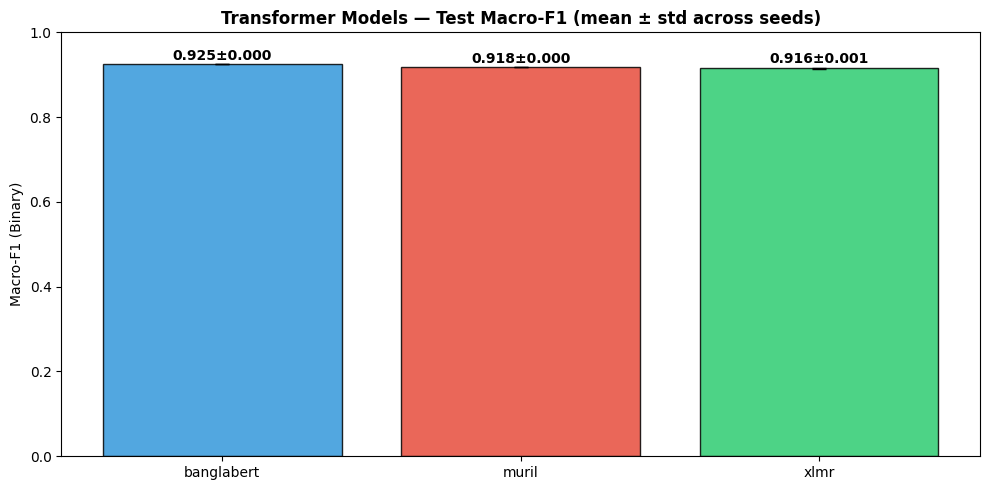

In [12]:
if len(all_results) == 0:
    print("⚠️ No results to display. Training failed for all runs.")
else:
    # ── Build summary table ────────────────────────────────────────────────────
    summary_rows = []
    for r in all_results:
        row = {"model": r["model"], "seed": r["seed"], "best_val_f1": r["best_val_f1"]}
        for task_name, task_metrics in r["test_metrics"].items():
            for metric_name, metric_val in task_metrics.items():
                row[f"{task_name}_{metric_name}"] = metric_val
        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))

    # ── Average across seeds ───────────────────────────────────────────────────
    print("\n── Averaged across seeds (mean ± std) ──")
    numeric_cols = [c for c in summary_df.columns if c not in ["model", "seed"]]
    avg_df = summary_df.groupby("model")[numeric_cols].agg(["mean", "std"]).round(4)
    print(avg_df.to_string())

    # Save
    summary_df.to_csv(f"{OUTPUT_DIR}/transformer_results_all.csv", index=False)
    avg_df.to_csv(f"{OUTPUT_DIR}/transformer_results_averaged.csv")
    print(f"\n✅ Saved results to {OUTPUT_DIR}")

    # ── Visualization ──────────────────────────────────────────────────────────
    if "binary_macro_f1" in summary_df.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        models = summary_df["model"].unique()
        x = np.arange(len(models))

        means = [summary_df[summary_df["model"]==m]["binary_macro_f1"].mean() for m in models]
        stds  = [summary_df[summary_df["model"]==m]["binary_macro_f1"].std() for m in models]

        bars = ax.bar(x, means, yerr=stds, capsize=5, color=["#3498db", "#e74c3c", "#2ecc71"][:len(models)],
                      edgecolor="black", alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(models)
        ax.set_ylabel("Macro-F1 (Binary)")
        ax.set_title("Transformer Models — Test Macro-F1 (mean ± std across seeds)", fontweight="bold")
        ax.set_ylim(0, 1.0)
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0 if pd.isna(s) else s) + 0.01,
                    f"{m:.3f}±{0.0 if pd.isna(s) else s:.3f}", ha="center", fontsize=10, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/transformer_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("⚠️ 'binary_macro_f1' not found in results – skipping plot.")


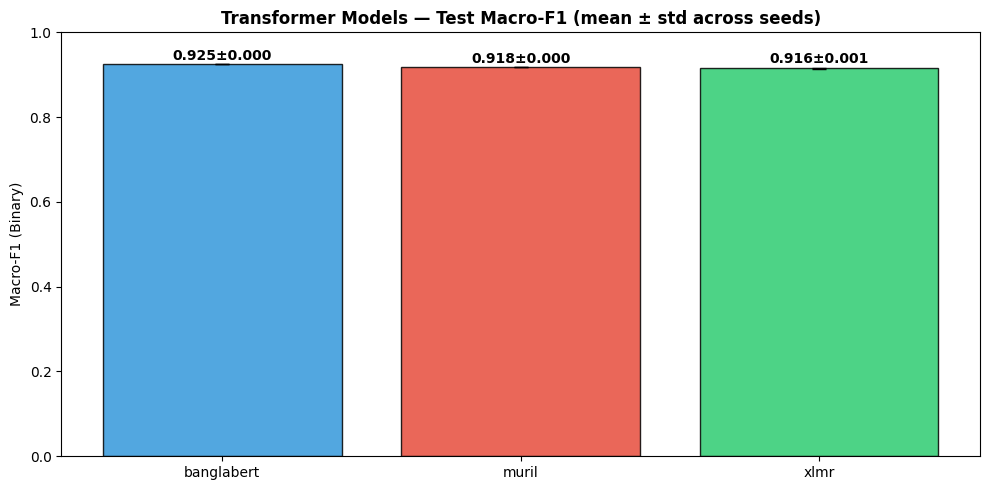

In [13]:
# ── Visualization (standalone cell — safe even if training failed) ─────────
if 'all_results' not in dir() or len(all_results) == 0:
    print("⚠️ No results available. Run the training cell first.")
elif 'summary_df' not in dir():
    print("⚠️ summary_df not found. Re-run the results cell above.")
elif len(summary_df) > 0 and "binary_macro_f1" in summary_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    models = summary_df["model"].unique()
    x = np.arange(len(models))
    
    means = [summary_df[summary_df["model"]==m]["binary_macro_f1"].mean() for m in models]
    stds  = [summary_df[summary_df["model"]==m]["binary_macro_f1"].std() for m in models]
    
    bars = ax.bar(x, means, yerr=stds, capsize=5, color=["#3498db", "#e74c3c", "#2ecc71"][:len(models)],
                  edgecolor="black", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel("Macro-F1 (Binary)")
    ax.set_title("Transformer Models — Test Macro-F1 (mean ± std across seeds)", fontweight="bold")
    ax.set_ylim(0, 1.0)
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
                f"{m:.3f}±{s:.3f}", ha="center", fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../outputs/models/transformer_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠️ 'binary_macro_f1' not found in results – skipping plot.")


---
**Next:** Notebook `06_ensemble_and_threshold.ipynb` — Build weighted logits ensemble from the saved logits, tune thresholds, and evaluate final system.